In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Activation , Dense , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adamax

In [3]:
train_data_path = '.../Covid19-dataset/train'
filepaths =[] 
labels = []

folds = os.listdir(train_data_path)  #links
for fold in folds:
    f_path = os.path.join(train_data_path , fold)
    filelists = os.listdir(f_path) # imagelinks 
    for file in filelists:
        filepaths.append(os.path.join(f_path , file))
        labels.append(fold)

Fseries = pd.Series(filepaths , name = 'file paths')
Lseries = pd.Series(labels , name = 'label')
train_df = pd.concat([Fseries , Lseries] , axis = 1)

In [5]:
test_data_path = '.../Covid19-dataset/test'
filepaths =[]
labels = []

folds = os.listdir(test_data_path)
for fold in folds:
    f_path = os.path.join(test_data_path , fold)
    filelists = os.listdir(f_path)
    for file in filelists:
        filepaths.append(os.path.join(f_path , file))
        labels.append(fold)

Fseries = pd.Series(filepaths , name = 'file paths')
Lseries = pd.Series(labels , name = 'label')
test_df = pd.concat([Fseries , Lseries] , axis = 1)

In [6]:
train_df[100:]

,file paths,label
100,/kaggle/input/covid19-image-dataset/Covid19-da...,Viral Pneumonia
101,/kaggle/input/covid19-image-dataset/Covid19-da...,Viral Pneumonia
102,/kaggle/input/covid19-image-dataset/Covid19-da...,Viral Pneumonia
103,/kaggle/input/covid19-image-dataset/Covid19-da...,Viral Pneumonia
104,/kaggle/input/covid19-image-dataset/Covid19-da...,Viral Pneumonia
...,...,...
246,/kaggle/input/covid19-image-dataset/Covid19-da...,Covid
247,/kaggle/input/covid19-image-dataset/Covid19-da...,Covid
248,/kaggle/input/covid19-image-dataset/Covid19-da...,Covid
249,/kaggle/input/covid19-image-dataset/Covid19-da...,Covid


In [7]:
train_df['label'].unique()

array(['Normal', 'Viral Pneumonia', 'Covid'], dtype=object)

In [8]:
train_df['label'].value_counts()

label
Covid              111
Normal              70
Viral Pneumonia     70
Name: count, dtype: int64

In [9]:
train_df

,file paths,label
0,/kaggle/input/covid19-image-dataset/Covid19-da...,Normal
1,/kaggle/input/covid19-image-dataset/Covid19-da...,Normal
2,/kaggle/input/covid19-image-dataset/Covid19-da...,Normal
3,/kaggle/input/covid19-image-dataset/Covid19-da...,Normal
4,/kaggle/input/covid19-image-dataset/Covid19-da...,Normal
...,...,...
246,/kaggle/input/covid19-image-dataset/Covid19-da...,Covid
247,/kaggle/input/covid19-image-dataset/Covid19-da...,Covid
248,/kaggle/input/covid19-image-dataset/Covid19-da...,Covid
249,/kaggle/input/covid19-image-dataset/Covid19-da...,Covid


In [13]:
test_df['label'].unique()

array(['Normal', 'Viral Pneumonia', 'Covid'], dtype=object)

In [14]:
valid,test = train_test_split(test_df,train_size= 0.5,shuffle=True,random_state=45)

In [15]:
img_size = (224,224)
batch_size = 16
tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()


train_gen = tr_gen.flow_from_dataframe(train_df ,x_col='file paths',y_col='label',target_size=img_size,
                                        class_mode = 'categorical' ,
                                        color_mode = 'rgb' ,
                                        shuffle = True ,
                                        batch_size =batch_size)


test_gen = ts_gen.flow_from_dataframe(test ,x_col= 'file paths' ,y_col = 'label' ,target_size = img_size, 
                                      class_mode = 'categorical' ,
                                      color_mode= 'rgb' ,
                                      shuffle = False ,
                                      batch_size = batch_size)


valid_gen = ts_gen.flow_from_dataframe(valid ,x_col = 'file paths' ,y_col = 'label' ,target_size = img_size, 
                                       class_mode = 'categorical',
                                       color_mode = 'rgb' ,
                                       shuffle= True,
                                       batch_size = batch_size)

Found 251 validated image filenames belonging to 3 classes.
Found 33 validated image filenames belonging to 3 classes.
Found 33 validated image filenames belonging to 3 classes.


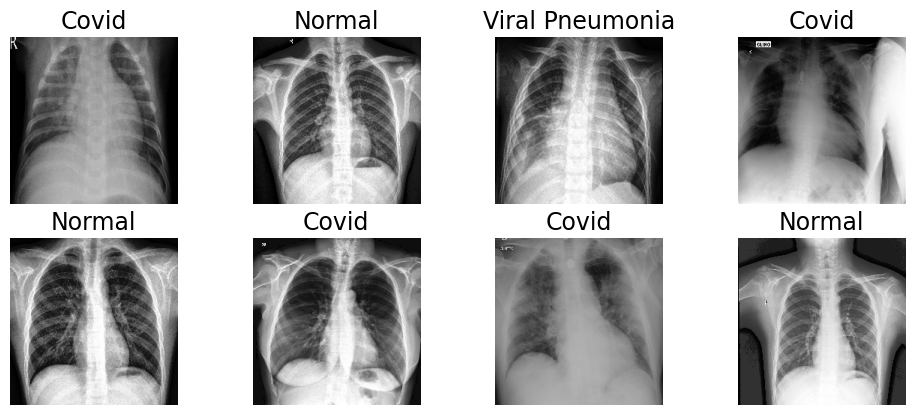

In [30]:
gen_dict = train_gen.class_indices

classes = list(gen_dict.keys())

images , labels = next(train_gen)


plt.figure(figsize= (12,10))
for i in range(8):
    plt.subplot(4,4,i+1)
    image = images[i] / 255
    plt.imshow(image, cmap= 'gray')
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name , color = 'Black' , fontsize= 17)
    plt.axis('off')
plt.show()

In [27]:
len(train_gen.class_indices)

3

In [19]:
img_shape = (img_size[0], img_size[1], 3)
num_class = len(classes)

In [20]:

base_model = tf.keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling='max'
)

model = Sequential([
    base_model,
    BatchNormalization(),
    Dense(128, activation='relu'),   
    Dropout(0.2),
    Dense(num_class, activation='softmax')
])

model.compile(optimizer=Adamax(learning_rate=0.0005),
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

I0000 00:00:1772374291.380894      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772374291.386854      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,782,787 (56.39 MB)

 Trainable params: 14,781,763 (56.39 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(x= train_gen , epochs = 25 , verbose = 1 , validation_data = valid_gen ,
                   validation_steps = None , shuffle = False,callbacks=[early_stop])

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 386ms/step - accuracy: 0.8592 - loss: 0.3785 - val_accuracy: 0.2727 - val_loss: 15.7716
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 367ms/step - accuracy: 0.8549 - loss: 0.4273 - val_accuracy: 0.2727 - val_loss: 10.0598
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 367ms/step - accuracy: 0.9149 - loss: 0.2878 - val_accuracy: 0.2727 - val_loss: 4.5714
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 327ms/step - accuracy: 0.9001 - loss: 0.2630 - val_accuracy: 0.3030 - val_loss: 5.6143
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 375ms/step - accuracy: 0.9074 - loss: 0.3004 - val_accuracy: 0.5152 - val_loss: 2.8141
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 368ms/step - accuracy: 0.9575 - loss: 0.1765 - val_accuracy: 0.4848 - val_loss: 2.8434
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 357ms/step - accuracy: 0.9285 - loss: 0.2318 - val_accuracy: 0.3636 - val_loss: 2.9664
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 364ms/step - accuracy: 0.9430 - loss: 0.1959 - val_accuracy: 

In [24]:
print(f'accuracy: {model.evaluate(test_gen)[1]*100:.2f}%')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8925 - loss: 0.2376
accuracy: 87.88%


In [ ]:
model.save('Covid_19_VGG116.h5')